# Creating the linear regression model for our project

In [7]:
!pip install scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

def perform_linear_regression(csv_file_path):
    # 1. Load the data
    df = pd.read_csv(csv_file_path)

    # 2. Separate Features (X) and Target (y)
    # X = all columns except the last one | y = only the last column
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # 3. Split into Training and Testing sets (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Initialize and Train the Model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 5. Make Predictions
    y_pred = model.predict(X_test)

    # 6. Calculate 6 Error Measurements
    r2 = metrics.r2_score(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = metrics.mean_absolute_error(y_test, y_pred)
    # Handle division by zero for MAPE if y_test contains 0
    mape = np.mean(np.abs((y_test - y_pred) / np.clip(y_test, 1e-9, None))) * 100
    max_err = metrics.max_error(y_test, y_pred)

    # Display Metrics
    print(f"--- Model Performance for {csv_file_path} ---")
    print(f"R² Score:          {r2:.4f}")
    print(f"Mean Squared Err:  {mse:.4f}")
    print(f"Root MSE:          {rmse:.4f}")
    print(f"Mean Absolute Err: {mae:.4f}")
    print(f"Mean Abs Pct Err:  {mape:.2f}%")
    print(f"Max Error:         {max_err:.4f}")

    # 7. Bisector Line Plot (Predicted vs Actual)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Data Points')

    # Create the Bisector Line (y = x)
    all_vals = np.concatenate([y_test, y_pred])
    min_val, max_val = all_vals.min(), all_vals.max()
    plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label='Perfect Fit')

    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Linear Regression: Predicted vs Actual\n(R² = {r2:.3f})')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

--- Model Performance for mapped_dataset_Normalized_version.csv ---
R² Score:          -0.0002
Mean Squared Err:  0.2498
Root MSE:          0.4998
Mean Absolute Err: 0.4993
Mean Abs Pct Err:  24289602660.87%
Max Error:         0.5657


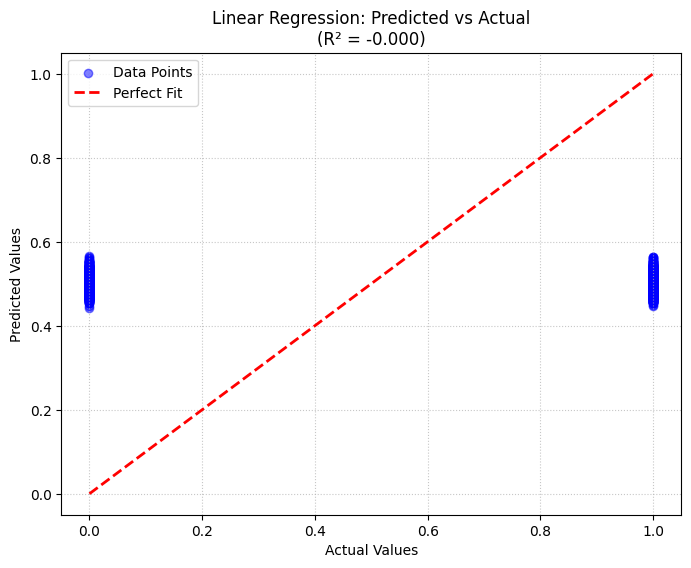

In [11]:
perform_linear_regression("mapped_dataset_Normalized_version.csv")